# RamanBench — Exploring Precomputed Results

This notebook explores the precomputed v0.1 results in detail.

## Ecosystem

| Resource | Link |
|---|---|
| **raman-data** | [GitHub](https://github.com/ml-lab-htw/raman_data) · [PyPI](https://pypi.org/project/raman-data/) |
| **raman-bench** | [GitHub](https://github.com/ml-lab-htw/RamanBench) · [PyPI](https://pypi.org/project/raman-bench/) |
| **Leaderboard** | [HuggingFace](https://huggingface.co/spaces/HTW-KI-Werkstatt/RamanBench) |
| **Paper** | [arXiv TBD](https://arxiv.org/abs/TBD) |

In [1]:
from raman_bench import Leaderboard
import pandas as pd
import matplotlib.pyplot as plt

lb = Leaderboard.from_precomputed()

In [2]:
# Overall ranking
print('=== Overall Leaderboard ===')
lb.rank()

=== Overall Leaderboard ===


,Rank,model_id,Model,Category,Elo,Score,Avg Rank,Improvability,Train Time s,Infer. s/1K
0,1,AUTOGLUON,"AutoGluon 1.5 (extreme, 4h)",AutoML,1558.0,0.7974,3.9,20.3,1776.3,220.7
1,2,REALTABPFN-V2.5,TabPFN v2.5,Tabular Foundation,1529.0,0.7594,4.3,24.1,89.6,100.8
2,3,TABICL,TabICL,Tabular Foundation,1443.0,0.6430,5.7,35.7,39.9,130.3
3,4,REALTABPFN-V2,TabPFN v2,Tabular Foundation,1402.0,0.6397,6.3,36.0,77.6,146.4
4,5,MITRA,MITRA,Tabular Foundation,1312.0,0.4923,8.1,50.8,827.4,626.5
5,6,REZERONET,ReZeroNet,Raman-Specific,1133.0,0.3023,11.9,69.8,44.6,23.1
6,7,TABDPT,TabDPT,Tabular Foundation,1136.0,0.2920,11.9,70.8,12.3,80.2
7,8,LR,Logistic Reg.,Traditional ML,1002.0,0.2279,15.1,77.2,37.2,41.2
8,9,REALMLP,RealMLP,Deep Learning,1111.0,0.2198,13.1,78.0,1935.5,71.1
9,10,PLS,PLS,Traditional ML,1004.0,0.2180,15.4,78.2,29.7,19.2


In [3]:
# Classification vs Regression
print('=== Classification Top 10 ===')
display(lb.rank('classification').head(10))

print('=== Regression Top 10 ===')
display(lb.rank('regression').head(10))

=== Classification Top 10 ===


,Rank,model_id,Model,Category,Elo,Score,Avg Rank,Improvability,Train Time s,Infer. s/1K
0,1,AUTOGLUON,"AutoGluon 1.5 (extreme, 4h)",AutoML,1558.0,0.7251,5.3,27.5,1776.3,220.7
1,2,REALTABPFN-V2.5,TabPFN v2.5,Tabular Foundation,1529.0,0.6667,6.9,33.3,89.6,100.8
2,3,TABICL,TabICL,Tabular Foundation,1443.0,0.6122,7.4,38.8,39.9,130.3
3,4,REZERONET,ReZeroNet,Raman-Specific,1133.0,0.5398,8.0,46.0,44.6,23.1
4,5,ARSENAL,ARSENAL,TS Classification,1240.0,0.4417,10.5,55.8,2876.0,2790.3
5,6,REALTABPFN-V2,TabPFN v2,Tabular Foundation,1402.0,0.4398,10.0,56.0,77.6,146.4
6,7,ROCKET,ROCKET,TS Classification,1244.0,0.4015,10.3,59.9,1270.3,140.5
7,8,DEEPCNN,DeepCNN,Raman-Specific,1006.0,0.3840,11.9,61.6,1280.1,63.5
8,9,RAMANNET,RamanNet,Raman-Specific,1028.0,0.3514,13.0,64.9,73.9,13.3
9,10,MITRA,MITRA,Tabular Foundation,1312.0,0.3469,13.1,65.3,827.4,626.5


=== Regression Top 10 ===


,Rank,model_id,Model,Category,Elo,Score,Avg Rank,Improvability,Train Time s,Infer. s/1K
0,1,AUTOGLUON,"AutoGluon 1.5 (extreme, 4h)",AutoML,1558.0,0.8092,3.7,19.1,1776.3,220.7
1,2,REALTABPFN-V2.5,TabPFN v2.5,Tabular Foundation,1529.0,0.7745,3.9,22.5,89.6,100.8
2,3,REALTABPFN-V2,TabPFN v2,Tabular Foundation,1402.0,0.6723,5.7,32.8,77.6,146.4
3,4,TABICL,TabICL,Tabular Foundation,1443.0,0.6480,5.4,35.2,39.9,130.3
4,5,MITRA,MITRA,Tabular Foundation,1312.0,0.5160,7.3,48.4,827.4,626.5
5,6,TABDPT,TabDPT,Tabular Foundation,1136.0,0.2863,11.7,71.4,12.3,80.2
6,7,REZERONET,ReZeroNet,Raman-Specific,1133.0,0.2637,12.5,73.6,44.6,23.1
7,8,REALMLP,RealMLP,Deep Learning,1111.0,0.2226,12.8,77.7,1935.5,71.1
8,9,PLS,PLS,Traditional ML,1004.0,0.2206,14.8,77.9,29.7,19.2
9,10,LR,Logistic Reg.,Traditional ML,1002.0,0.2093,15.3,79.1,37.2,41.2


In [4]:
# Dataset catalog
import importlib.resources
import pandas as pd

ref = importlib.resources.files("raman_bench") / "data" / "precomputed" / "datasets.csv"
with importlib.resources.as_file(ref) as p:
    datasets_df = pd.read_csv(p)
print(f"{len(datasets_df)} datasets")
datasets_df.head(10)


77 datasets


,dataset_id,Dataset,Domain,Task,Samples,Features,Classes / Targets,License
0,ht_raman_bio_catalysis_axp,Bio-Catalysis Monitoring of AXP,Biological,Regression,344,2048,4,CC BY 4.0
1,bioprocess_analytes_anton_532,Bioprocess Analytes Anton 532,Biological,Regression,270,1601,3,CC BY 4.0
2,bioprocess_analytes_anton_785,Bioprocess Analytes Anton 785,Biological,Regression,270,1001,3,CC BY 4.0
3,ecoli_metabolites,Bioprocess Analytes E. Coli Metabolites,Biological,Regression,1920,594,2,CC BY 4.0
4,bioprocess_analytes_kaiser,Bioprocess Analytes Kaiser,Biological,Regression,134,5472,3,CC BY 4.0
5,bioprocess_analytes_metrohm,Bioprocess Analytes Metrohm,Biological,Regression,399,1875,3,CC BY 4.0
6,bioprocess_analytes_mettler_toledo,Bioprocess Analytes Mettler Toledo,Biological,Regression,275,2901,3,CC BY 4.0
7,bioprocess_analytes_tec5,Bioprocess Analytes Tec5,Biological,Regression,395,2911,3,CC BY 4.0
8,bioprocess_analytes_timegate,Bioprocess Analytes Timegate,Biological,Regression,133,486,3,CC BY 4.0
9,bioprocess_analytes_tornado,Bioprocess Analytes Tornado,Biological,Regression,385,3001,3,CC BY 4.0


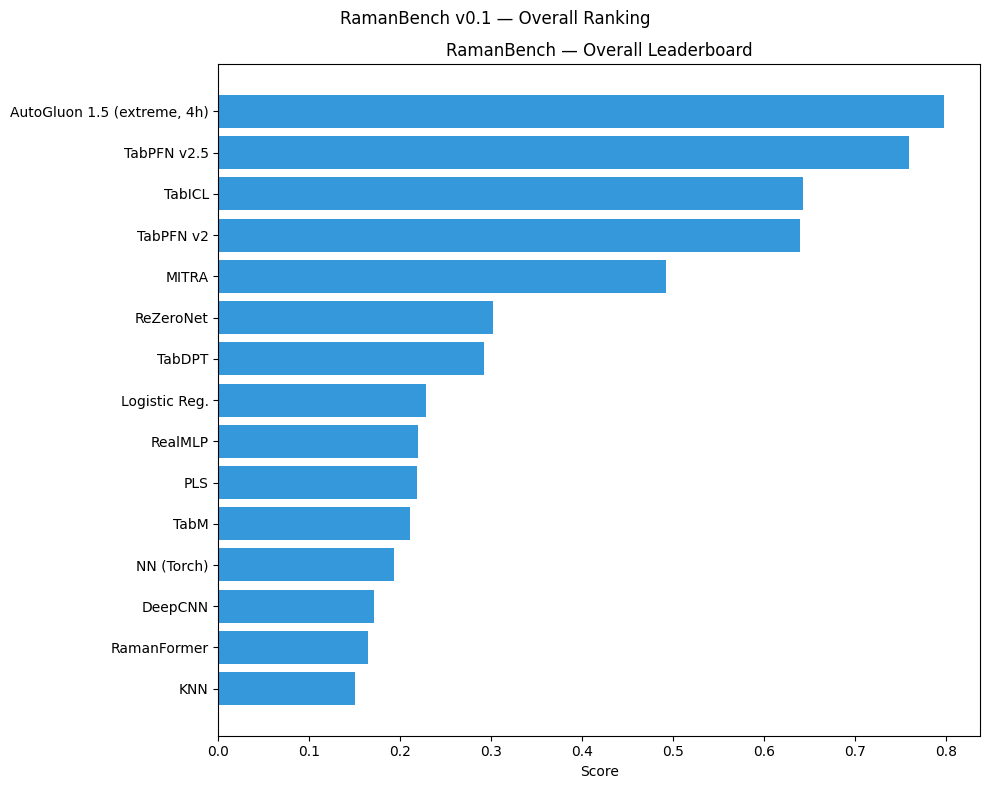

In [5]:
# Plot
fig = lb.plot(task="overall", n_top=15)
plt.suptitle("RamanBench v0.1 — Overall Ranking")
plt.tight_layout()
plt.show()
